<a href="https://colab.research.google.com/github/abiduldul/Numerical-Method/blob/main/Materi%203/Linear_Regression_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  BAGIAN 1: LINEAR REGRESSION

  Tabel perhitungan:
  i     xi       yi       xi^2     xi*yi   
  ---------------------------------------------
  1     1.0      5.1      1.0      5.10    
  2     2.0      5.9      4.0      11.80   
  3     3.0      6.3      9.0      18.90   
  ---------------------------------------------
  Sum   6.0      17.3     14.0     35.80   

  Normal Equations:
    3a  + 6.0b  = 17.3
    6.0a + 14.0b = 35.8

  Solusi:
    a = 4.5667
    b = 0.6000

  Fungsi hasil: f(x) = 4.5667 + 0.6000x

  Phi (sum of squared errors) = 0.026667


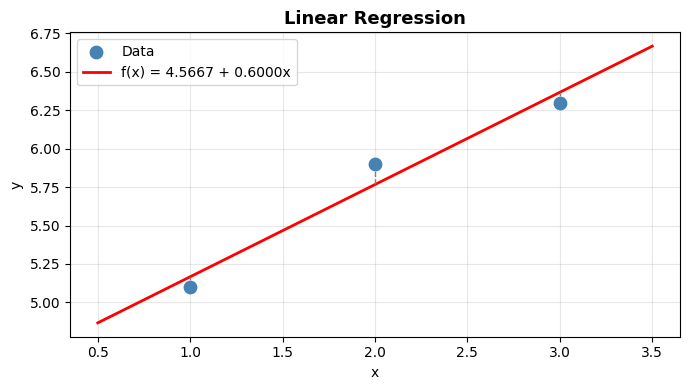

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
#  BAGIAN 1: LINEAR REGRESSION
#  Contoh dari Slide (Example 1)
#  Data: x = [1, 2, 3], y = [5.1, 5.9, 6.3]
#  Model: f(x) = a + b*x
# ============================================================

print("=" * 60)
print("  BAGIAN 1: LINEAR REGRESSION")
print("=" * 60)

# --- Data ---
x1 = np.array([1, 2, 3], dtype=float)
y1 = np.array([5.1, 5.9, 6.3], dtype=float)
n1 = len(x1)

# --- Hitung suku-suku yang dibutuhkan ---
sum_x   = np.sum(x1)
sum_y   = np.sum(y1)
sum_x2  = np.sum(x1**2)
sum_xy  = np.sum(x1 * y1)

print("\n  Tabel perhitungan:")
print(f"  {'i':<5} {'xi':<8} {'yi':<8} {'xi^2':<8} {'xi*yi':<8}")
print("  " + "-"*45)
for i in range(n1):
    print(f"  {i+1:<5} {x1[i]:<8.1f} {y1[i]:<8.1f} {x1[i]**2:<8.1f} {x1[i]*y1[i]:<8.2f}")
print("  " + "-"*45)
print(f"  {'Sum':<5} {sum_x:<8.1f} {sum_y:<8.1f} {sum_x2:<8.1f} {sum_xy:<8.2f}")

# --- Normal Equations: [n, Σx; Σx, Σx²] [a; b] = [Σy; Σxy] ---
A1 = np.array([[n1,     sum_x],
               [sum_x,  sum_x2]])
B1 = np.array([sum_y, sum_xy])

# --- Selesaikan sistem persamaan ---
sol1 = np.linalg.solve(A1, B1)
a1, b1 = sol1[0], sol1[1]

print(f"\n  Normal Equations:")
print(f"    {n1}a  + {sum_x}b  = {sum_y}")
print(f"    {sum_x}a + {sum_x2}b = {sum_xy}")

print(f"\n  Solusi:")
print(f"    a = {a1:.4f}")
print(f"    b = {b1:.4f}")
print(f"\n  Fungsi hasil: f(x) = {a1:.4f} + {b1:.4f}x")

# --- Hitung Phi (jumlah kuadrat error) ---
y1_pred = a1 + b1 * x1
phi1 = np.sum((y1_pred - y1)**2)
print(f"\n  Phi (sum of squared errors) = {phi1:.6f}")

# --- Plot ---
fig1, ax1 = plt.subplots(figsize=(7, 4))
x1_line = np.linspace(0.5, 3.5, 100)
y1_line = a1 + b1 * x1_line
ax1.scatter(x1, y1, color='steelblue', s=80, zorder=5, label='Data')
ax1.plot(x1_line, y1_line, 'r-', linewidth=2,
         label=f'f(x) = {a1:.4f} + {b1:.4f}x')
for i in range(n1):
    ax1.plot([x1[i], x1[i]], [y1[i], y1_pred[i]], 'gray',
             linestyle='--', linewidth=1)
ax1.set_title('Linear Regression', fontsize=13, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()